In [1]:
import networkx as nx
from networkx.algorithms import community
import matplotlib.pyplot as plt

### Criar uma rede simples

In [2]:
G = nx.Graph()

connections = [
    ("A", "B"),
    ("A", "C"),
    ("B", "D"),
    ("C", "D"),
    ("C", "E"),
    ("E", "F"),
]

G.add_edges_from(connections)

In [3]:
connections

[('A', 'B'), ('A', 'C'), ('B', 'D'), ('C', 'D'), ('C', 'E'), ('E', 'F')]

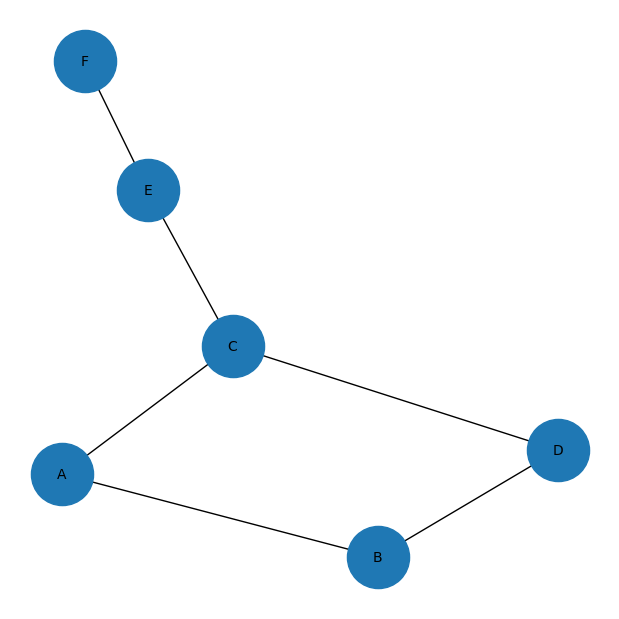

In [4]:
#Visualizar a rede

plt.figure(figsize=(6,6))
nx.draw(G, with_labels=True, node_size=2000, font_size=10)
plt.show()

### Métricas básicas

Grau (quem tem mais conexões)

In [10]:
degree = dict(G.degree())
ranking = sorted(degree.items(), key=lambda x: x[1], reverse=True)

print(ranking)

[('C', 3), ('A', 2), ('B', 2), ('D', 2), ('E', 2), ('F', 1)]


Centralidade de grau (normaliza a importância dos nós)

In [6]:
degree_centrality = nx.degree_centrality(G)
print(degree_centrality)

{'A': 0.4, 'B': 0.4, 'C': 0.6000000000000001, 'D': 0.4, 'E': 0.4, 'F': 0.2}


Betweenness centrality (ponte entre grupos)

In [7]:
betweenness = nx.betweenness_centrality(G)
print(betweenness)

{'A': 0.15000000000000002, 'B': 0.05, 'C': 0.65, 'D': 0.15000000000000002, 'E': 0.4, 'F': 0.0}


### Descobrir comunidades
grupos naturais dentro da rede

In [8]:
communities = community.greedy_modularity_communities(G)

for i, c in enumerate(communities):
    print(f"Comunidade {i+1}: {list(c)}")

Comunidade 1: ['D', 'A', 'B', 'C']
Comunidade 2: ['F', 'E']


### Importância
nós maiores = mais importantes

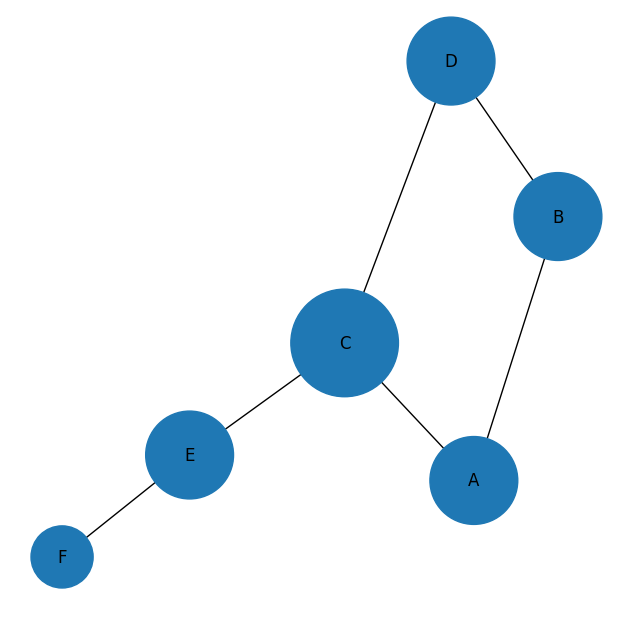

In [9]:
sizes = [v * 10000 for v in degree_centrality.values()]

plt.figure(figsize=(6,6))
nx.draw(
    G,
    with_labels=True,
    node_size=sizes
)
plt.show()